In [1]:
# created by Yann Buchholzer and Julius Zimmler
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# Create datasample, calculate radius², pi, sigma and number of points inside the circle

def pi_x(experiments, pairs, dimension):
    
    points = np.random.uniform(low = -1.0, high = 1.0, size = (dimension, pairs, experiments)) # generating the points
    radius_squared = (points**2).sum(axis=0) 
    inside_the_circle = (radius_squared <= 1)
    inside_the_square = ((-1.0 <= points[0]) & (points[0] <= 1.0) & 
                         (-1.0 <= points[1]) & (points[1] <= 1.0))
    pi_by_4 = inside_the_circle.sum(axis=0) / inside_the_square.sum(axis=0)
    pi = 4 * pi_by_4
    sigma = np.sqrt(4*inside_the_circle.sum()/(pairs-1))
    
    return radius_squared, pi,sigma, inside_the_circle

## 1.1 Just do one big experiment

In [3]:
# Experimental setup

experiments = 1
dimension = 2
pairs = 10000

# calculate radius², pi, sigma and number of points inside the circle (indicator variable)

radius_squared, pi_1,sigma, inside_the_circle = pi_x(experiments,pairs,dimension)

print("The mean of this experiment is",pi_1.mean(), ", with a standard deviation of ",sigma, ".")



The mean of this experiment is 3.132 , with a standard deviation of  1.7698342383746373 .


Since we only have one experiment and therefor only one estimate for pi, it is difficult to give a reasonable standard deviation using the given formula. But we can treat every indicator variable produced by a pair as its own estimate (0 or 4) and calculate a standard deviation this way.

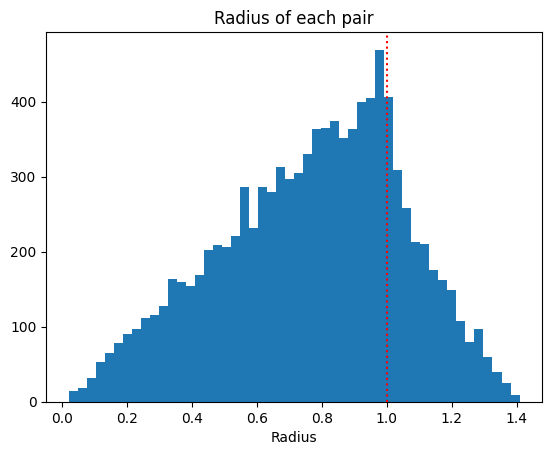

In [4]:
# Histogramm of radius

plt.hist(np.sqrt(radius_squared), bins = 50)
plt.title("Radius of each pair")
plt.xlabel("Radius")
plt.axvline(1, color = "red", linestyle = 'dotted') 
plt.show()


### Explanation:

The shape of the histogram comes from the fact that the pairs are uniformly distributed on the surface and the surface scales not linearly but quadraticly (with $r^{2}$). This explains the increasing number of points up to radius=1.0. There is simple put just more space and so it is more likely for pairs to fall here, while still remaining uniformly distributed. After radius=1.0 the shape is explained by the fact that the values of each coordinate of each pair is constrained to be 1 at its maximum. So to reach a radius over one  ("meaning the pair is placed in the corners of the square") becomes increasingly unlikely as it puts a high demand on both values (both values have to be high). In other words the fallof would not happen at one if the variables were not defined to be 1 at there maximum. If the radius of the circle was to be 2 and the square would be scaled accordingly the fallof would happen at 2 and so on.

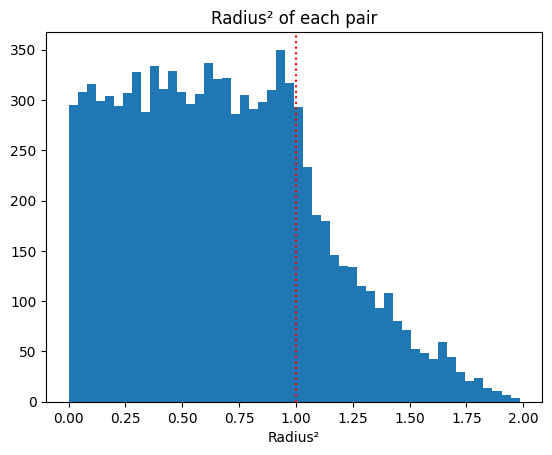

In [5]:
# Histogramm of radius

plt.hist(radius_squared, bins = 50)
plt.title("Radius² of each pair")
plt.xlabel("Radius²")
plt.axvline(1, color = "red", linestyle = 'dotted') 
plt.show()

### Explanation:

We have seen above how the pairs are positioned as a function of radius as a result of surface area scaling with $r^{2}$. First we want to mention that positions with radii smaller than one also have squared radii smaller than one (radii greater one remain greater one when squared). Generally speaking pairs do not cross the radius=1 border. But the squared radii are pushed away from the value 1 when compared to the previous histogram, since $x \cdot x \leq 1$ if $x\leq 1$. This counters the discussed linear distribution from the previous histogram giving us a constant distribution up to $r^{2}=1$. By the same logic we get a steaper decline for $r^{2} > 1$ when compared to the histogram of the radius. 

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_9839/2018383590.py:2: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(np.pi, color='red', label = "true value of $\pi$")
/tmp/ipykernel_9839/2018383590.py:4: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(pi_1.mean(), linestyle = 'dotted', label = 'mean value of $\pi$')


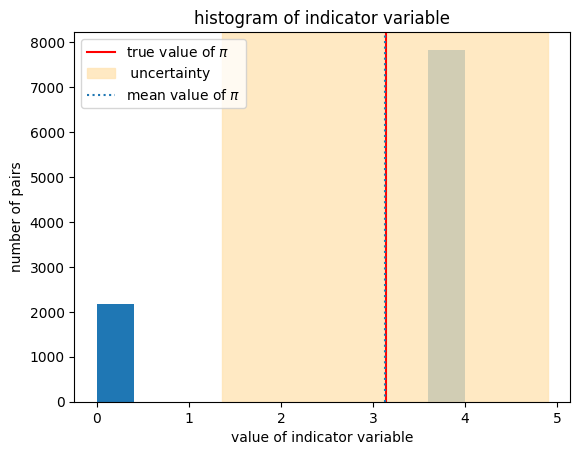

In [6]:
# histogram of the indicator variable

plt.hist(4*inside_the_circle)
plt.axvline(np.pi, color='red', label = "true value of $\pi$")
plt.axvspan(pi_1.mean() - sigma, pi_1.mean() + sigma, alpha=0.8, color = "moccasin" ,label= " uncertainty"  )
plt.axvline(pi_1.mean(), linestyle = 'dotted', label = 'mean value of $\pi$')
plt.title("histogram of indicator variable")
plt.xlabel("value of indicator variable")
plt.ylabel('number of pairs')
plt.legend()

plt.show()

## 1.2 Split into 100 experiments

In [7]:
# New experimental setup

experiments = 100
dimension = 2
pairs = 100

# Calculated pi 

pi_2 = pi_x(experiments,pairs,dimension)[1]

print("Estimate π_x for each experiment:\n", pi_2)
print("The mean of this experiment is", pi_2.mean(), "while the standard derivation is",
pi_2.std())


Estimate π_x for each experiment:
 [3.2  3.08 2.88 3.08 3.16 2.88 3.08 3.24 3.36 3.12 3.2  3.08 3.24 3.36
 3.08 2.96 3.4  2.92 2.84 3.   3.12 2.88 3.48 3.08 3.08 3.24 3.12 3.2
 3.28 2.88 2.84 3.12 3.12 2.88 3.4  3.08 2.8  3.2  2.8  3.32 3.2  3.24
 2.96 3.12 3.28 3.   3.32 3.44 3.48 3.32 2.92 3.16 3.12 3.08 3.04 3.32
 3.2  2.76 3.32 3.32 3.04 3.36 3.16 3.32 3.08 3.08 3.   3.16 3.16 3.
 3.36 3.   3.16 3.2  3.32 3.28 3.4  3.04 2.96 2.92 2.72 3.28 3.08 3.16
 3.16 3.16 3.2  3.   3.36 2.96 3.32 3.16 3.12 2.88 3.08 3.   3.08 3.44
 3.2  3.2 ]
The mean of this experiment is 3.1323999999999996 while the standard derivation is 0.17127241459149223


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_9839/2517237827.py:2: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(np.pi, color='red', label = "true value of $\pi$")
/tmp/ipykernel_9839/2517237827.py:5: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(pi_2.mean(), linestyle = 'dotted', label = 'mean value of $\pi$')
/tmp/ipykernel_9839/2517237827.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.title("histogram of $\pi$ estimates (100X, 100P, $\pi$)")


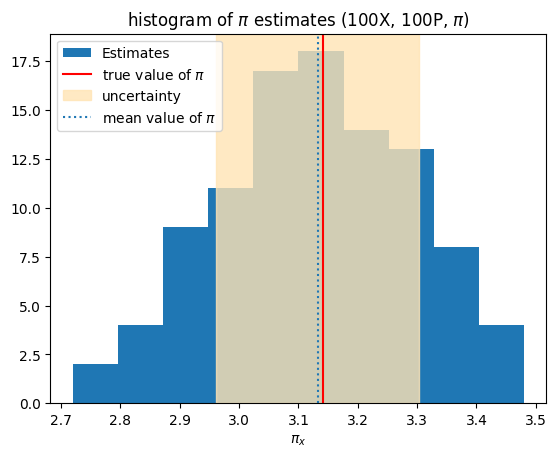

In [8]:
# Plot a histogram of the estimates

plt.hist(pi_2, label = "Estimates")
plt.axvline(np.pi, color='red', label = "true value of $\pi$")
plt.axvspan(pi_2.mean() - pi_2.std(), pi_2.mean() + pi_2.std(), alpha=0.8, color = "moccasin", 
            label = "uncertainty"  )
plt.axvline(pi_2.mean(), linestyle = 'dotted', label = 'mean value of $\pi$')
plt.title("histogram of $\pi$ estimates (100X, 100P, $\pi$)")
plt.xlabel("$π_x$")
plt.legend()

plt.show()

## 1.3 A Zillion Little Experiments

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_9839/500248574.py:13: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(np.pi, color='red', label = "true value of $\pi$")
/tmp/ipykernel_9839/500248574.py:14: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(pi_3.mean(), linestyle = 'dotted', label = 'mean value of $\pi$')
/tmp/ipykernel_9839/500248574.py:16: SyntaxWarning: invalid escape sequence '\p'
  plt.title("histogram of $\pi$ estimates (10000X, 1P)")
/tmp/ipykernel_9839/615266900.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  sigma = np.sqrt(4*inside_the_circle.sum()/(pairs-1))


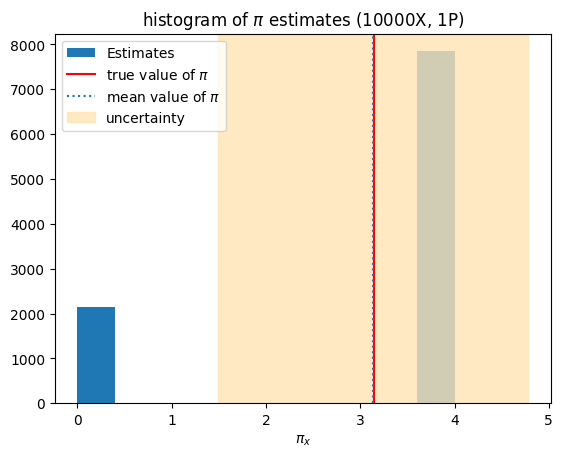

In [9]:
# New experimental setup

experiments = 10000
dimension = 2
pairs = 1

# Calculated pi 

pi_3 = pi_x(experiments,pairs,dimension)[1]

# Plot a histogram of the estimates

plt.hist(pi_3, label = "Estimates")
plt.axvline(np.pi, color='red', label = "true value of $\pi$")
plt.axvline(pi_3.mean(), linestyle = 'dotted', label = 'mean value of $\pi$')
plt.axvspan(pi_3.mean() - pi_3.std(), pi_3.mean() + pi_3.std(), alpha=0.8, color = "moccasin" ,label= "uncertainty"  )
plt.title("histogram of $\pi$ estimates (10000X, 1P)")
plt.xlabel("$π_x$")
plt.legend()

plt.show()

In [10]:
print("The mean of this experiment is", pi_3.mean(), "while the standard derivation is",
pi_3.std())

The mean of this experiment is 3.1384 while the standard derivation is 1.644398199950365


### Explanation:

Yes this result is obvously very familiar. We have seen nearly identical results in our treatment of the 1 experiment, 10000 pairs trial. We can say that it makes no difference which of these options we take.

## 1.4 Stop and think

In [11]:
# Different results: Mean with uncertainty

print(pi_1.mean(),'+-',sigma)
print(pi_2.mean(),'+-',pi_2.std())
print(pi_3.mean(),'+-',pi_3.std())
print(np.pi)

3.132 1.7698342383746373
3.1323999999999996 0.17127241459149223
3.1384 1.644398199950365
3.141592653589793


All computational results are close to the true result of pi. The difference between these methods lies in different uncertainties.

As answered above there is a way to introduce a sesible notion of uncertainty into tho 1.1 run.

As discussed there is no difference (most importantly also no conceptual difference) between a reasonable treatment of 1X, 10000P and 10000X, 1P as we can see by the values above. However we can reduce the uncertainty by a full order of magnitude when splittig our runs equally into experiments and pairs within these experiments. So we can clearly say it matters how we spent/organize our computing power.  


## 1.5 More Experiments vs. Longer Experiments

In [12]:
# Combination of pairs

pairs = np.array([10,100,1000,10000])
experiments = np.array([10,100,1000,10000])
X_P = []

# Store the results
pi_mean = np.zeros(16) #result of (X,P) experiment  
pi_all = [[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[]]
pi_std = np.zeros(16)

for a in range(len(pairs)):
    for c in range(len(experiments)):
        pi_mean[c*4+a] = pi_x(experiments[c],pairs[a],2)[1].mean()    # Final result of experiment (X,P)
        pi_std[c*4+a] = pi_x(experiments[c],pairs[a],2)[1].std()      # Uncertainty of experiment (X,P)
        pi_all[c*4+a] = pi_x(experiments[c],pairs[a],2)[1]            # all calculated pi_x
        X_P = np.append(X_P,(experiments[c],pairs[a]))                # List of used combination
        
pi_tot_std = np.sqrt(1/15*np.sum((pi_mean-pi_mean.mean())**2)) 
        
#print("The final estimate of pi is",pi_mean.mean(),"+-",pi_tot_std)
#print(pi_all)
#print(X_P)

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_9839/3189900613.py:10: SyntaxWarning: invalid escape sequence '\p'
  axs[k][l].axvline(np.pi, color='red', label = "true value of $\pi$")
/tmp/ipykernel_9839/3189900613.py:11: SyntaxWarning: invalid escape sequence '\p'
  axs[k][l].axvline(pi_mean[k*4+l], linestyle = 'dotted', label = "mean value of $\pi$")


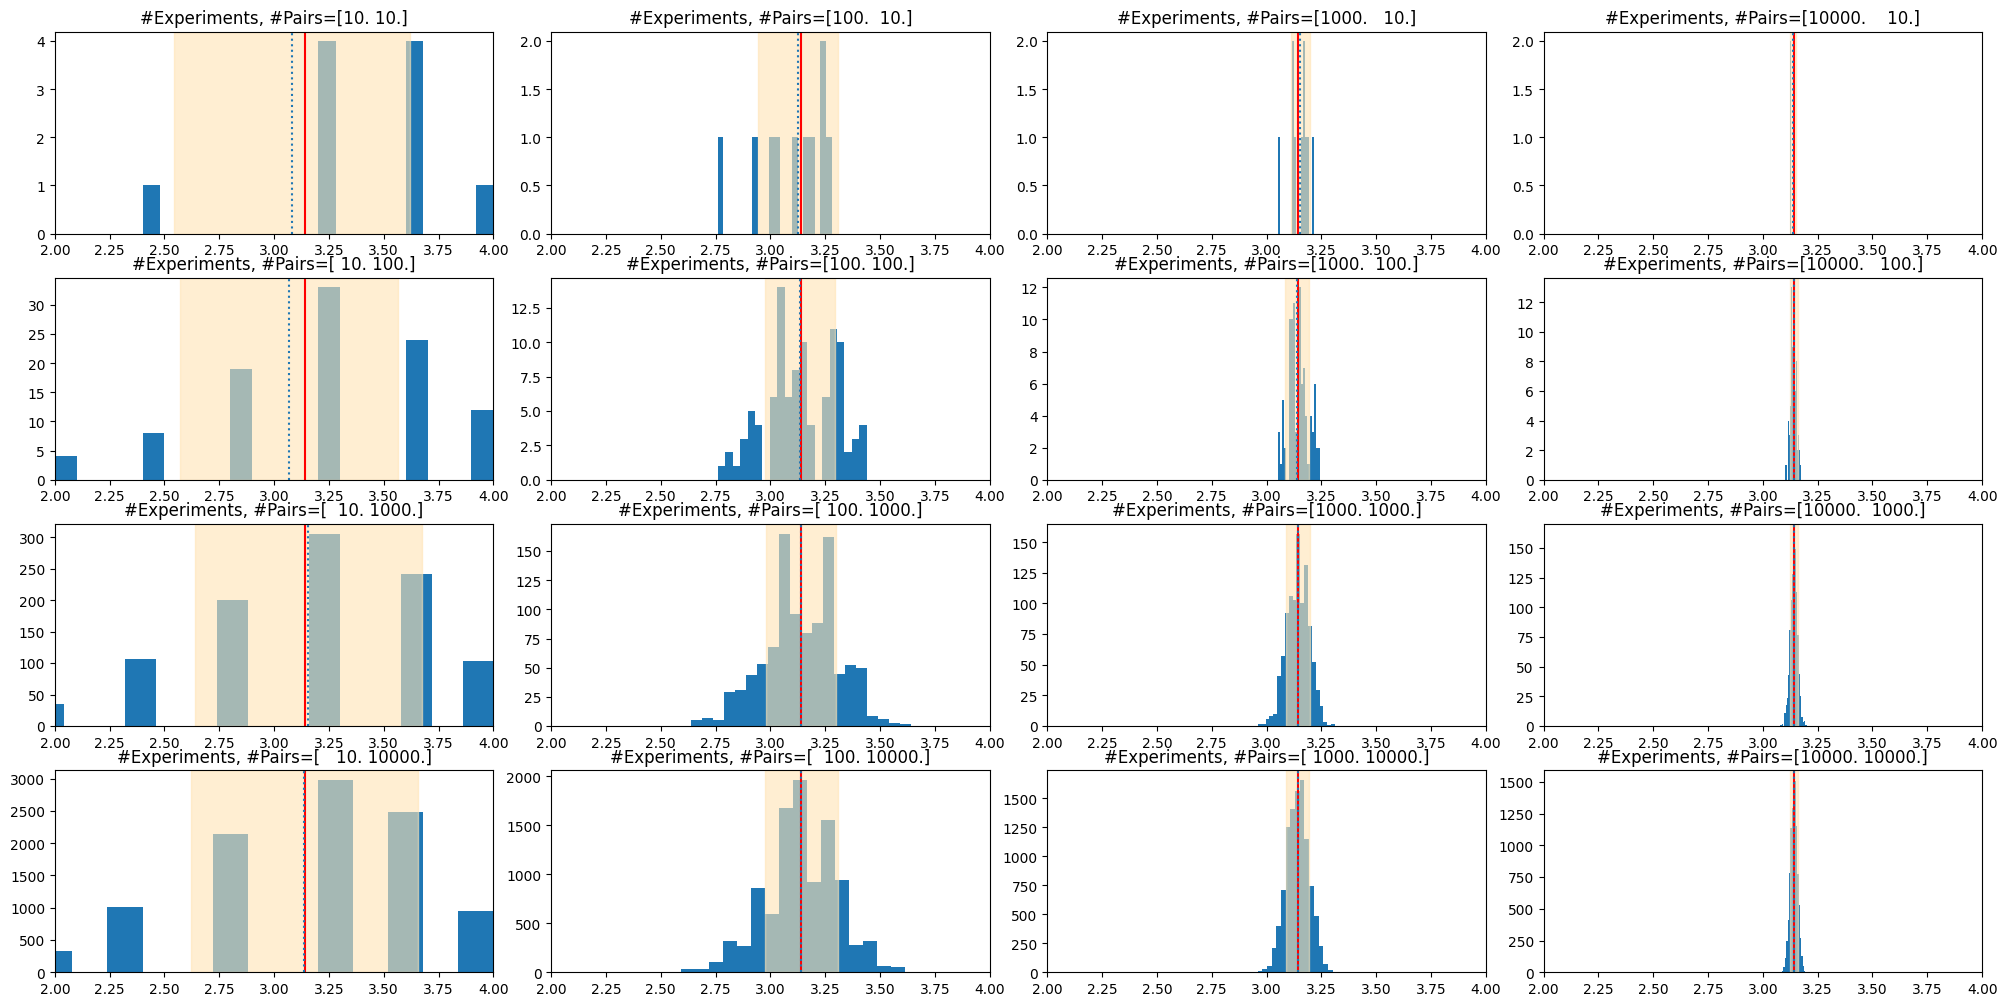

In [30]:
X_P = X_P.reshape(16,2)

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(20, 10))
fig.tight_layout() # Or equivalently,  "plt.tight_layout()"

# 16 histogramm  with same limits on x-axis
for k in range(4):
    for l in range(4):
        axs[k][l].set_xlim([2, 4])
        axs[k][l].hist(pi_all[k*4+l], label = "Estimates", bins = 20)
        axs[k][l].axvline(np.pi, color='red', label = "true value of $\pi$")
        axs[k][l].axvline(pi_mean[k*4+l], linestyle = 'dotted', label = "mean value of $\pi$")
        axs[k][l].axvspan(pi_mean[k*4+l] - pi_std[k*4+l], pi_mean[k*4+l] + pi_std[k*4+l], alpha=0.6, color = "moccasin" ,label= "uncertainty"  )
        axs[k][l].title.set_text(f"#Experiments, #Pairs={X_P[k*4+l]}")
        #axs[k][l].xlabel("$π_x$")
        #axs[k][l].legend()
plt.show()

Of course the best result is given by the run with 10000 experiments and 10000 pairs. But it might not be the most effective. WE see that our final result is always quit good, but the uncertainty shows big differeces. We can see that the number of experiments seems to be much more important than the number of pairs in each experiment.

In [4]:

# seperate the 16 results by fixed pairs
pi_std_fixed_pairs = pi_std.reshape(4,4)

# seperate the 16 results by fixed experiments
pi_std_fixed_experiments = pi_std_fixed_pairs.T


You should have the same number of pairs and experiment to minimize the uncertainty, if you have a fix X*P

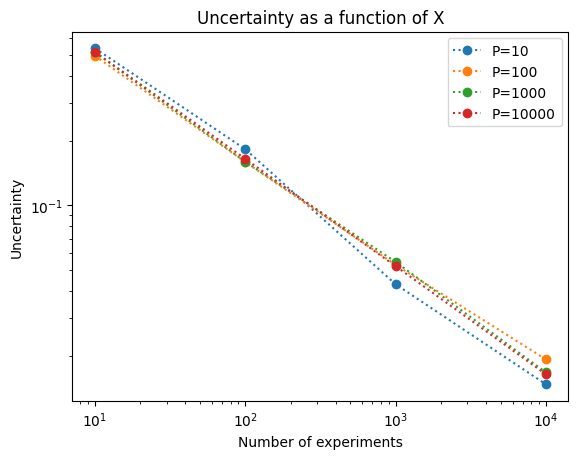

In [17]:
# log-log-plot with fixed number of pairs

plt.plot(experiments, pi_std_fixed_pairs[0], linestyle = ':', marker = 'o', label = 'P=10')
plt.plot(experiments, pi_std_fixed_pairs[1], linestyle = ':', marker = 'o', label = 'P=100')
plt.plot(experiments, pi_std_fixed_pairs[2], linestyle = ':', marker = 'o', label = 'P=1000')
plt.plot(experiments, pi_std_fixed_pairs[3], linestyle = ':', marker = 'o', label = 'P=10000')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of experiments')
plt.ylabel('Uncertainty')
plt.legend()
plt.title('Uncertainty as a function of X')
plt.show()

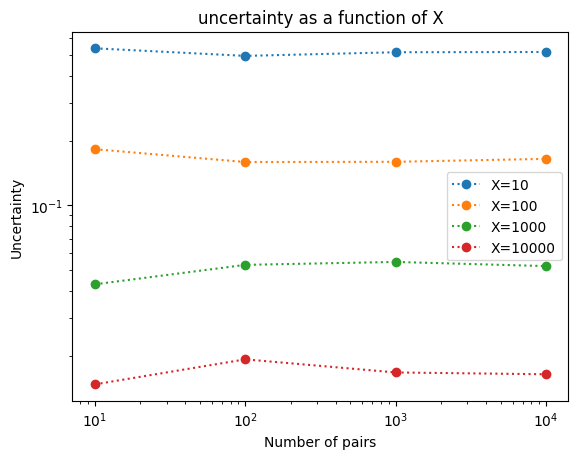

In [19]:
# log-log-plot with fixed number of experiments

plt.plot(pairs, pi_std_fixed_experiments[0], linestyle = ':', marker = 'o', label = 'X=10')
plt.plot(pairs, pi_std_fixed_experiments[1], linestyle = ':', marker = 'o', label = 'X=100')
plt.plot(pairs, pi_std_fixed_experiments[2], linestyle = ':', marker = 'o', label = 'X=1000')
plt.plot(pairs, pi_std_fixed_experiments[3], linestyle = ':', marker = 'o', label = 'X=10000')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of pairs')
plt.ylabel('Uncertainty')
plt.legend()
plt.title('uncertainty as a function of X')
plt.show()

With increasing number of pairs and fixed experiments the logharithm of the uncertainties is roughly constant, while it goes linearly down with fixed number of pairs and increasing experiments. This is in agreement with our observation from the earlier plots.